In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("C:/Users/ADMIN/Desktop/Priyadharshini PGP - Data Science/Project 1/austo_automobile .csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


In [4]:
print(data.dtypes)

Age                   int64
Gender               object
Profession           object
Marital_status       object
Education            object
No_of_Dependents      int64
Personal_loan        object
House_loan           object
Partner_working      object
Salary                int64
Partner_salary      float64
Total_salary          int64
Price                 int64
Make                 object
dtype: object


In [5]:
print("Missing values in columns:")
print(data.isnull().sum())

Missing values in columns:
Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64


In [6]:
print("duplicate in each column:")
print(data.duplicated().sum())

duplicate in each column:
0


In [7]:
data['Gender'].nunique()

4

In [8]:
data['Gender'] = data['Gender'].replace({'Femal': 'Female', 'Femle': 'Female'})
print (data['Gender'].value_counts())

Gender
Male      1199
Female     329
Name: count, dtype: int64


In [9]:
Gender_mode = data['Gender'].mode()[0]
data['Gender'] = data['Gender'].fillna(Gender_mode)
print(data['Gender'].value_counts())

Gender
Male      1252
Female     329
Name: count, dtype: int64


In [10]:
print(data.isnull().sum())

Age                   0
Gender                0
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64


In [11]:
data.loc[(data['Marital_status'] == 'Single') & (data['Partner_salary'].isnull()), 'Partner_salary'] = 0
married_mask = (data['Marital_status'] == 'Married') & (data['Partner_salary'].isnull())
data.loc[married_mask, 'Partner_salary'] = data['Total_salary'] - data['Salary']
print("Missing Partner_salary values filled.")

Missing Partner_salary values filled.


In [12]:
print(data.isnull().sum())

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64


In [39]:
df = pd.DataFrame(data)
df['Partner_salary'] = df['Partner_salary'].astype(int) 
df.describe()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
count,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000,1581.000000
mean,31.922201,2.457938,60392.220114,19233.776091,79625.996205,35597.722960
std,8.425978,0.943483,14674.825044,19670.391171,25545.857768,13633.636545
min,22.000000,0.000000,30000.000000,0.000000,30000.000000,18000.000000
25%,25.000000,2.000000,51900.000000,0.000000,60500.000000,25000.000000
50%,29.000000,2.000000,59500.000000,25100.000000,78000.000000,31000.000000
75%,38.000000,3.000000,71800.000000,38100.000000,95900.000000,47000.000000
max,54.000000,4.000000,99300.000000,80500.000000,171000.000000,70000.000000


In [40]:
data[['Gender','Profession', 'Marital_status', 'Education','Personal_loan', 'House_loan','Partner_working','Make']].describe()

,Gender,Profession,Marital_status,Education,Personal_loan,House_loan,Partner_working,Make
count,1581,1581,1581,1581,1581,1581,1581,1581
unique,2,2,2,2,2,2,2,3
top,Male,Salaried,Married,Post Graduate,Yes,No,Yes,Sedan
freq,1252,896,1443,985,792,1054,868,702


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1581 non-null   int64 
 1   Gender            1581 non-null   object
 2   Profession        1581 non-null   object
 3   Marital_status    1581 non-null   object
 4   Education         1581 non-null   object
 5   No_of_Dependents  1581 non-null   int64 
 6   Personal_loan     1581 non-null   object
 7   House_loan        1581 non-null   object
 8   Partner_working   1581 non-null   object
 9   Salary            1581 non-null   int64 
 10  Partner_salary    1581 non-null   int32 
 11  Total_salary      1581 non-null   int64 
 12  Price             1581 non-null   int64 
 13  Make              1581 non-null   object
dtypes: int32(1), int64(5), object(8)
memory usage: 166.9+ KB


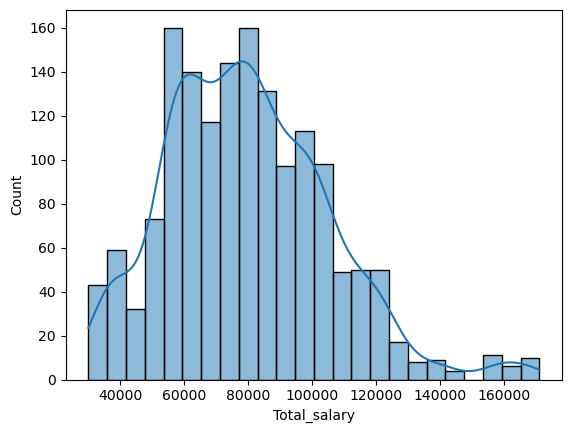

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=df, x='Total_salary', kde=True);


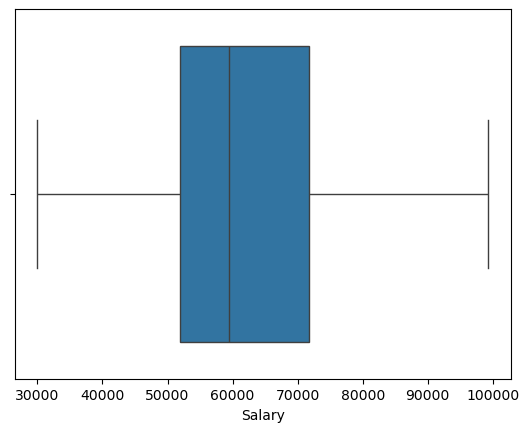

In [65]:
sns.boxplot(data=df, x='Salary');

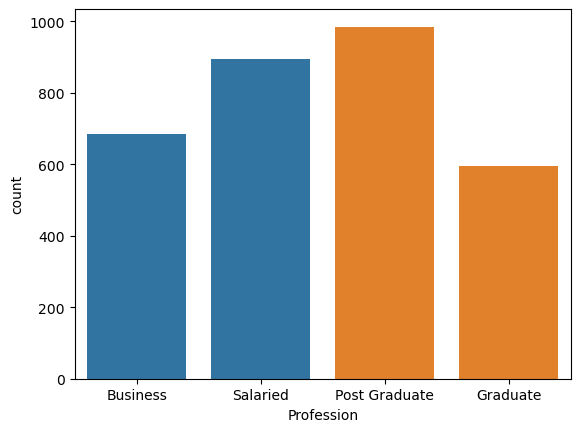

In [42]:
sns.countplot(data=df, x='Profession');
sns.countplot(data=df, x='Education');

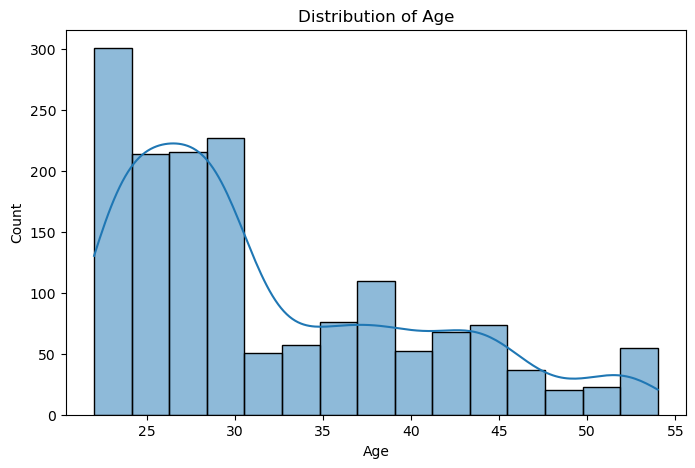

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', kde=True)
plt.title('Distribution of Age')
plt.show()

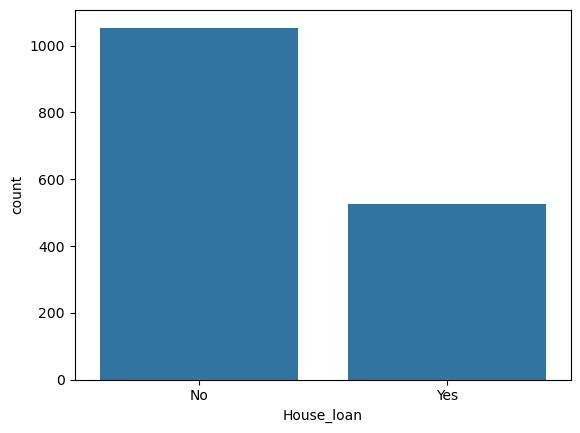

In [56]:
sns.countplot(data=df, x='House_loan');


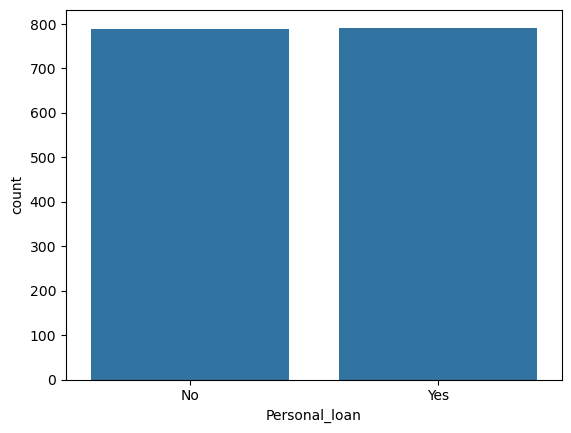

In [60]:
sns.countplot(data=df, x='Personal_loan');


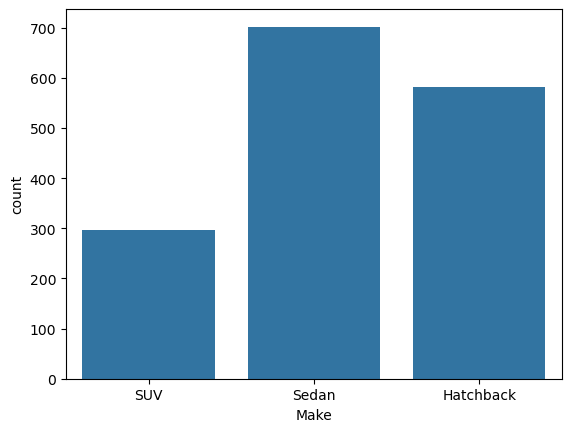

In [50]:
sns.countplot(data=df, x='Make');



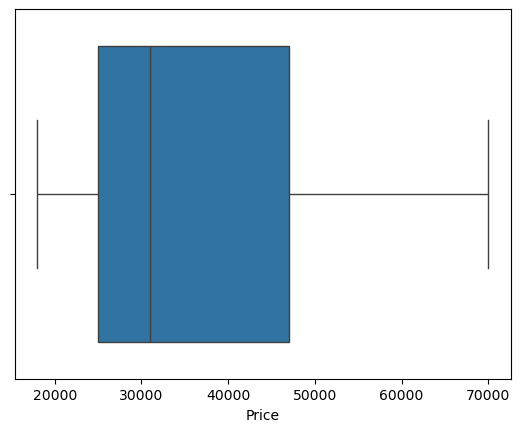

In [62]:
sns.boxplot(data=df, x='Price');




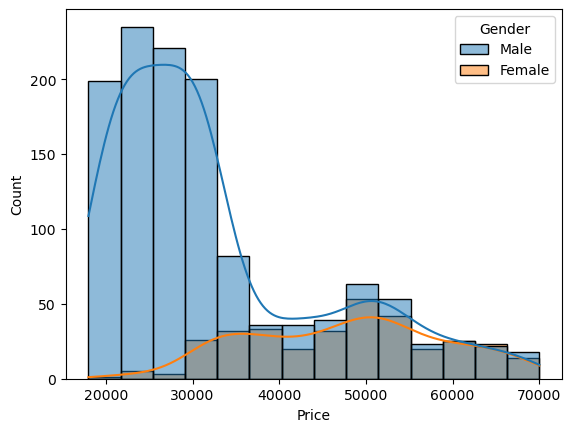

In [18]:
sns.histplot(data=df, x='Price', hue='Gender', kde=True);


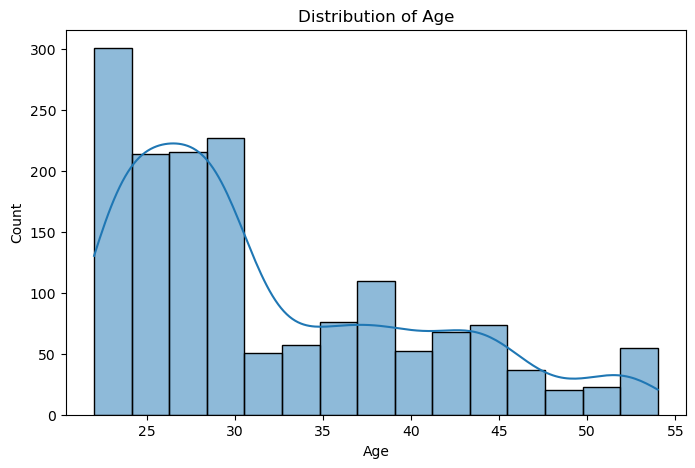

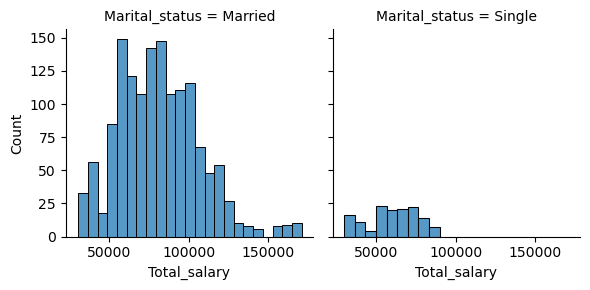

In [19]:
g = sns.FacetGrid(df, col="Marital_status")
g.map(sns.histplot, "Total_salary");

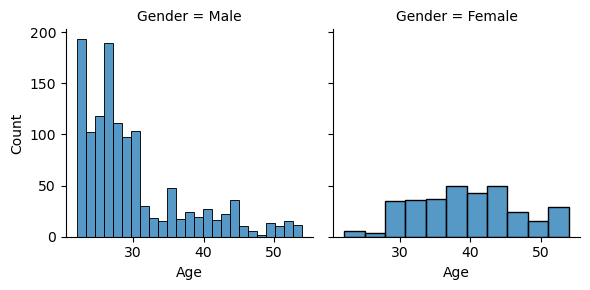

In [20]:
g = sns.FacetGrid(df, col="Gender")
g.map(sns.histplot, "Age");

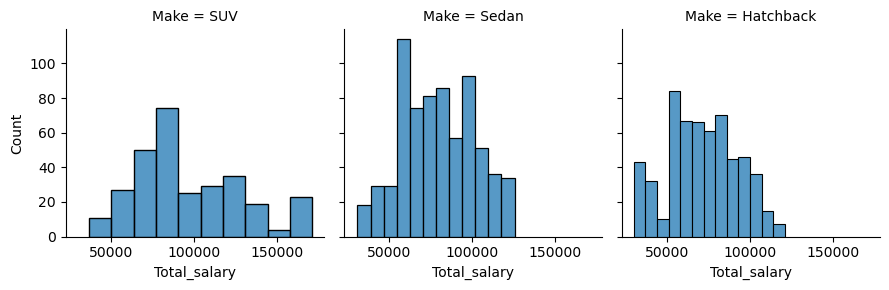

In [22]:
g = sns.FacetGrid(df, col="Make")
g.map(sns.histplot, "Total_salary");

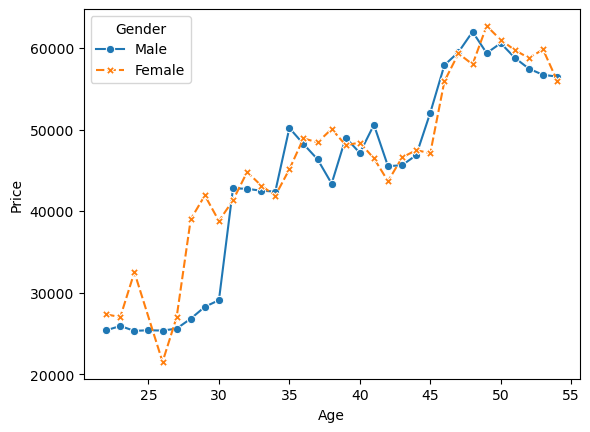

In [23]:
sns.lineplot(data = df , x = 'Age' , y = 'Price', hue="Gender", style="Gender",  errorbar = None, markers = True);

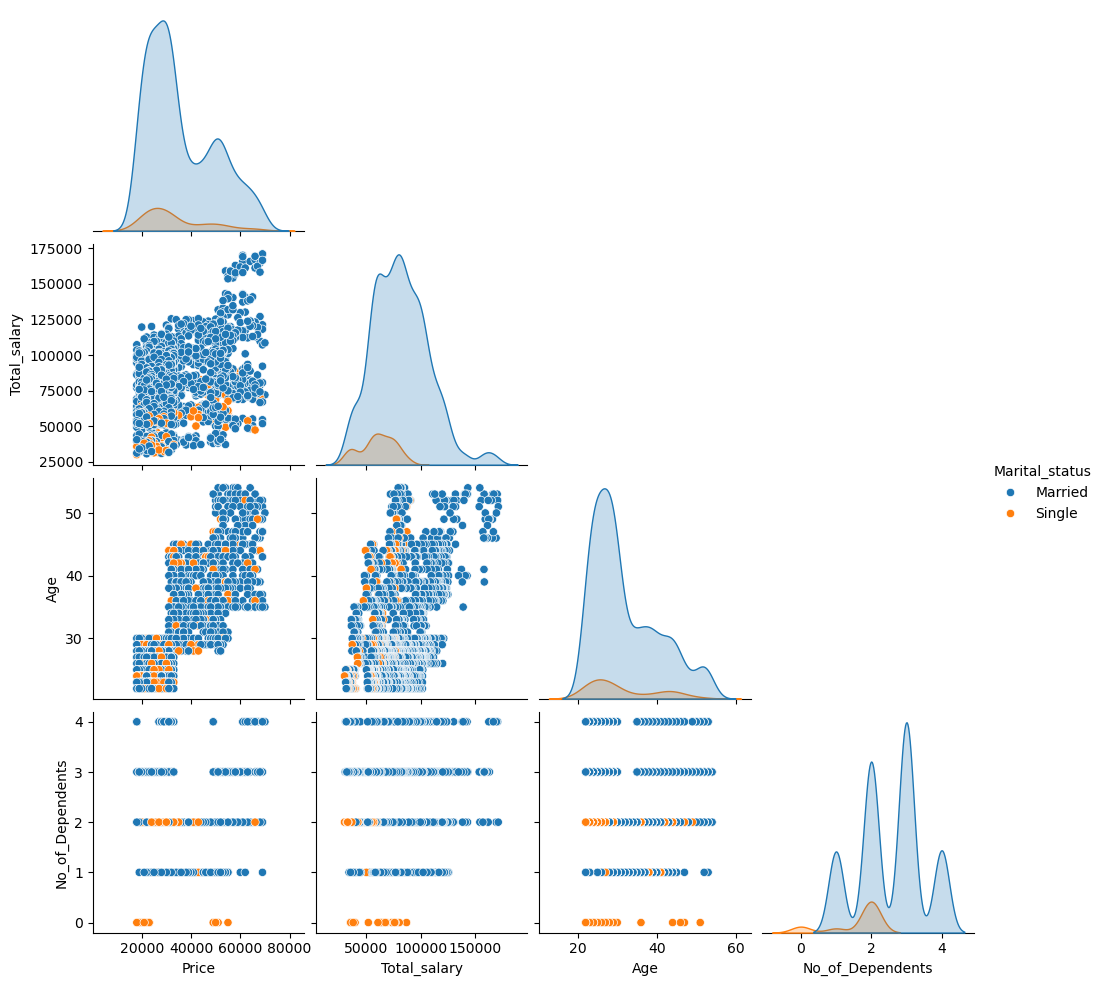

In [24]:
sns.pairplot(data=df, vars=['Price', 'Total_salary', 'Age', 'No_of_Dependents'], hue='Marital_status',corner=True);


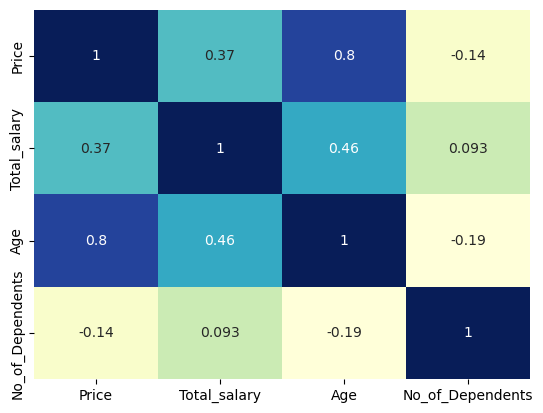

In [25]:
sns.heatmap(data=df[['Price','Total_salary', 'Age', 'No_of_Dependents']].corr(),annot=True, cbar=False,cmap='YlGnBu');

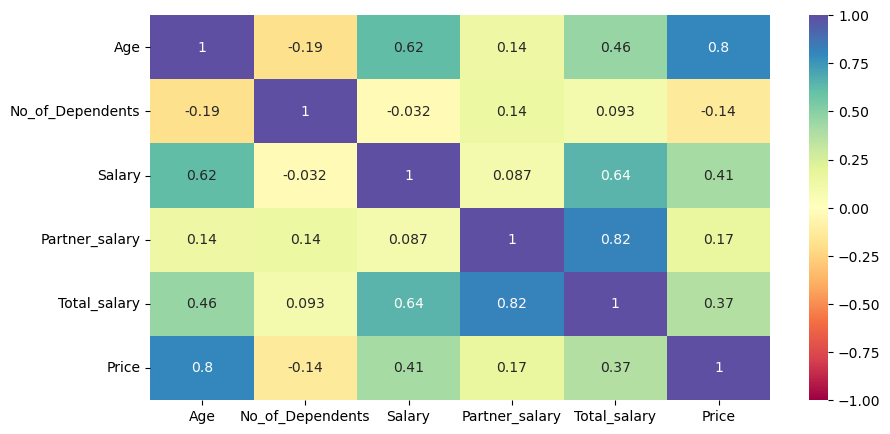

In [66]:
numerical_cols = ['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price']
plt.figure(figsize=(10, 5)) 
correlation_matrix = data[numerical_cols].corr() 
sns.heatmap(correlation_matrix, 
    annot=True, 
    cmap='Spectral', 
    vmin=-1, 
    vmax=1);

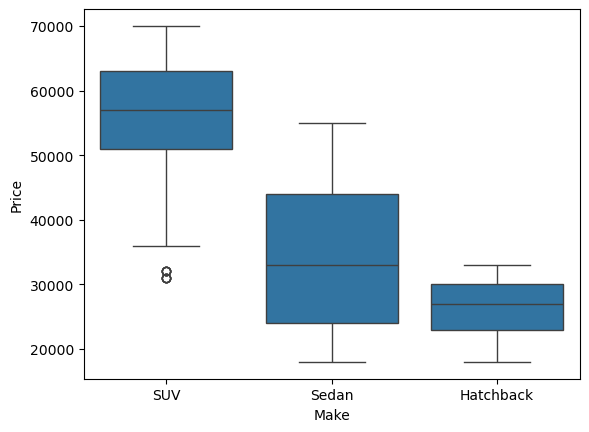

In [27]:
sns.boxplot(data=data,x='Make',y='Price')
plt.show()

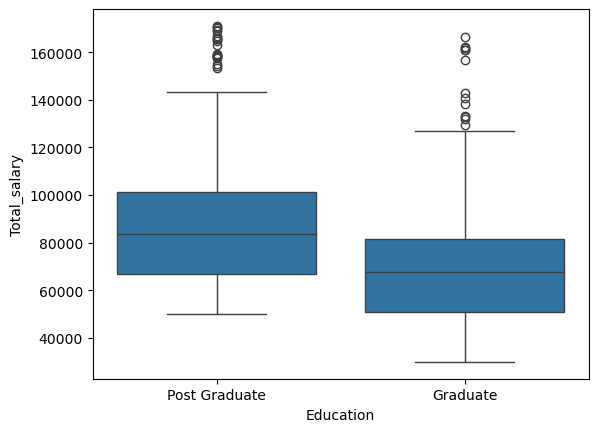

In [28]:
sns.boxplot(data=data,x='Education',y='Total_salary')
plt.show()


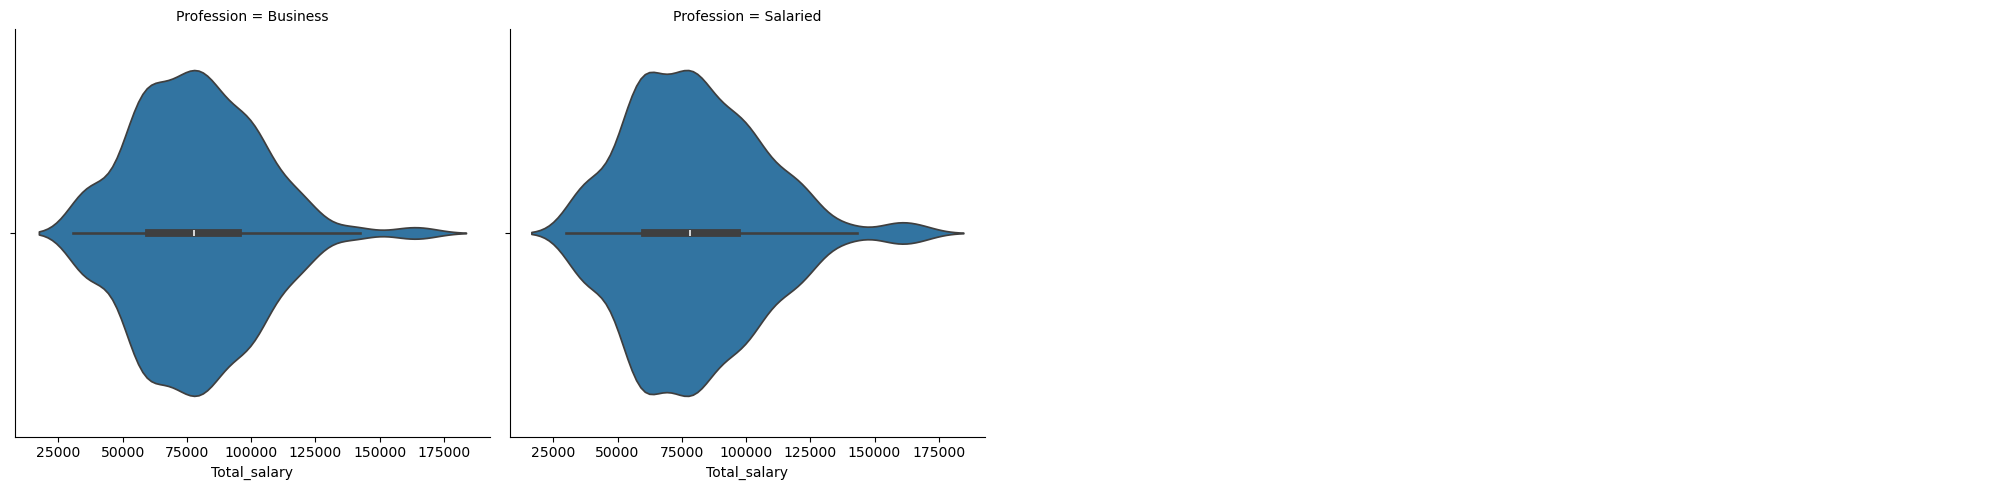

In [29]:
sns.catplot(x='Total_salary',
            col='Profession',
            data=data,
            col_wrap=4,
            kind="violin")
plt.show()


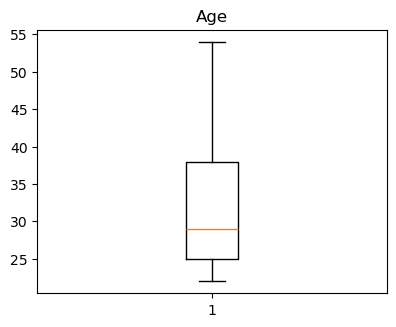

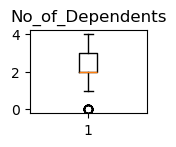

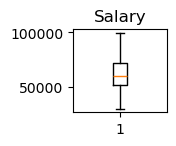

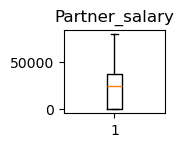

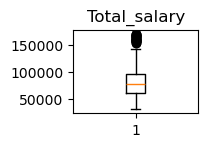

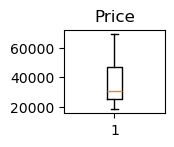

In [30]:
plt.figure(figsize=(15, 12))


for i, variable in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)
    plt.show()


Make    Hatchback        SUV      Sedan
Gender                                 
Female   4.559271  52.583587  42.857143
Male    45.287540   9.904153  44.808307


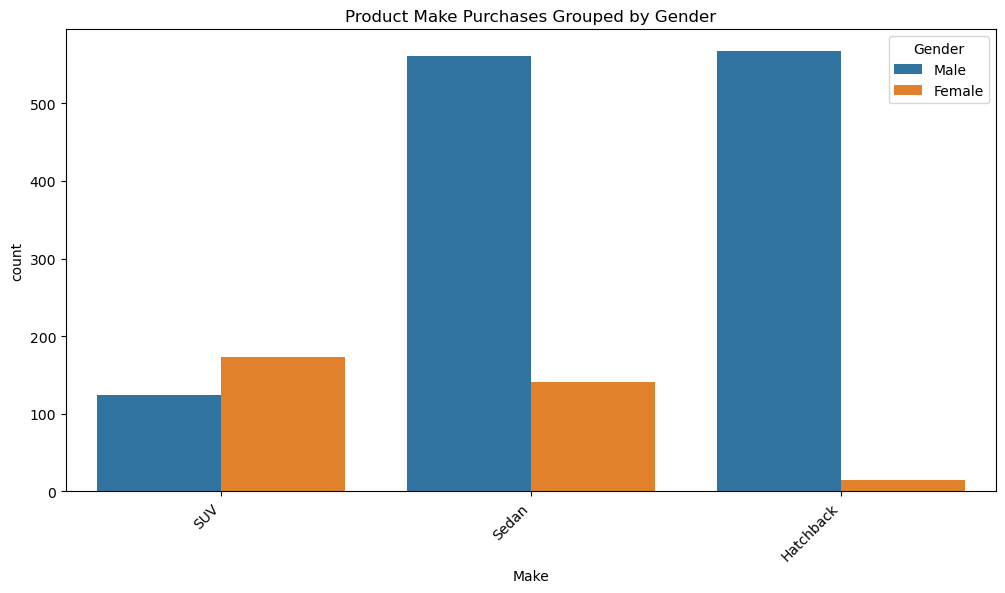

In [31]:
#1. Do men tend to prefer SUVs more compared to women?

#Analysis Plan: Gender vs. Make
make_by_gender = pd.crosstab(data['Gender'], data['Make'], normalize='index') * 100
print(make_by_gender)
plt.figure(figsize=(12, 6))
# Count the number of purchases for each Make, grouped by Gender
sns.countplot(data=data, x='Make', hue='Gender')
plt.title('Product Make Purchases Grouped by Gender')
plt.xticks(rotation=45, ha='right')
plt.show()

In [32]:
#2. What is the likelihood of a salaried person buying a Sedan?
#Analysis Plan: 


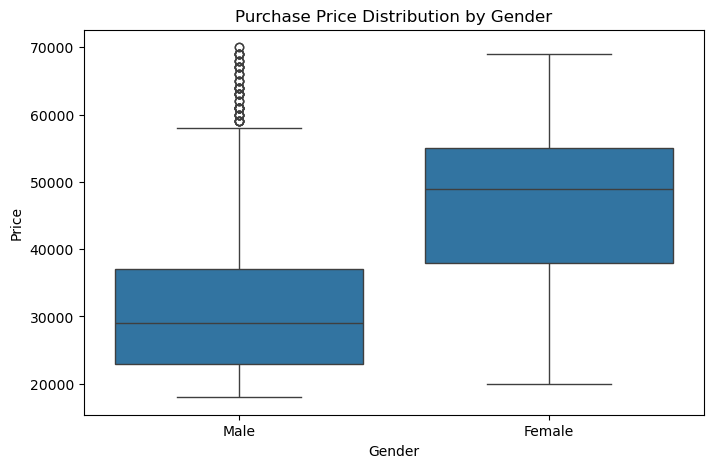

In [33]:
#3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?
#Proxy for SUV vs. Sedan
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='Gender', y='Price')
plt.title('Purchase Price Distribution by Gender')
plt.show()

price_by_gender_boxplot.png
Summary Statistics for Price by Gender:
            mean   median  count
Gender                          
Female  47705.17  49000.0    329
Male    32416.13  29000.0   1252


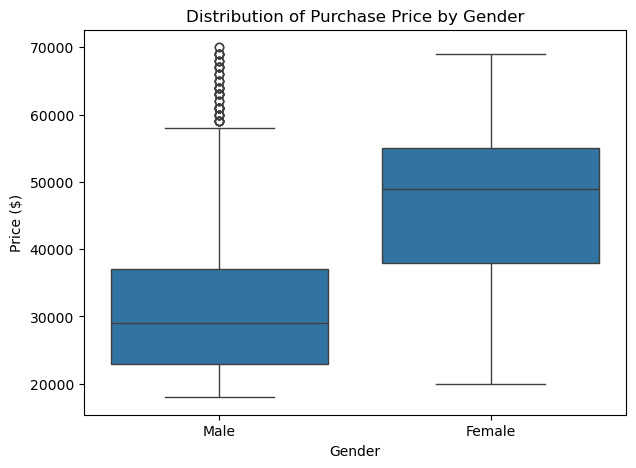

In [37]:
#4. How does the the amount spent on purchasing automobiles vary by gender?
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x='Gender', y='Price')
plt.title('Distribution of Purchase Price by Gender')
plt.xlabel('Gender')
plt.ylabel('Price ($)')
plt.savefig('price_by_gender_boxplot.png')
price_summary = data.groupby('Gender')['Price'].agg(['mean', 'median', 'count']).round(2)

print("price_by_gender_boxplot.png")
print("Summary Statistics for Price by Gender:")
print(price_summary)


In [35]:
#5. How much money was spent on purchasing automobiles by individuals who took a personal loan?
total_spent_by_loan = data.groupby('Personal_loan')['Price'].sum()

print("Total Money Spent on Automobiles Grouped by Personal Loan Status:")
print(total_spent_by_loan.round(2))

# Calculate the total spent only by those who took a personal loan ('Yes')
money_spent_by_loan_takers = total_spent_by_loan.get('Yes', 0)

print(f"\nMoney spent by individuals who took a personal loan: {money_spent_by_loan_takers:.2f}")

Total Money Spent on Automobiles Grouped by Personal Loan Status:
Personal_loan
No     28990000
Yes    27290000
Name: Price, dtype: int64

Money spent by individuals who took a personal loan: 27290000.00


price_by_partner_working_boxplot.png
Summary Statistics for Price by Partner Working Status:
                     mean   median  count
Partner_working                          
No               36000.00  31000.0    713
Yes              35267.28  31000.0    868


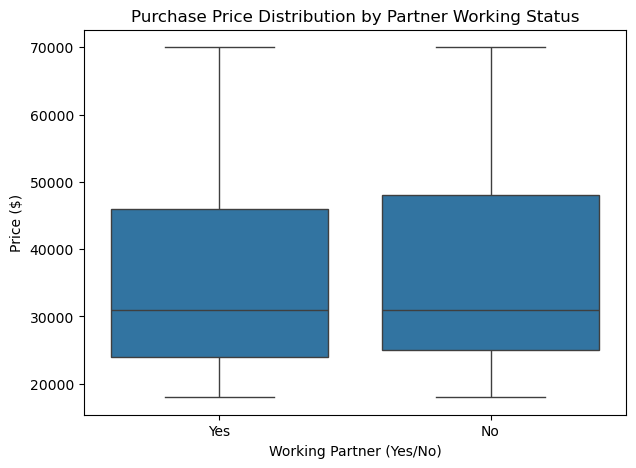

In [36]:
#6. How does having a working partner influence the purchase of higher-priced cars?
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x='Partner_working', y='Price', order=['Yes', 'No'])
plt.title('Purchase Price Distribution by Partner Working Status')
plt.xlabel('Working Partner (Yes/No)')
plt.ylabel('Price ($)')
plt.savefig('price_by_partner_working_boxplot.png')

# 2. Calculate summary statistics (mean, median, count)
price_summary_partner = data.groupby('Partner_working')['Price'].agg(['mean', 'median', 'count']).round(2)

print("price_by_partner_working_boxplot.png")
print("Summary Statistics for Price by Partner Working Status:")
print(price_summary_partner)